In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

/var/folders/7h/dvymb3m50bzg0j9yyrdvvn000000gn/T/ipykernel_90855/3035929060.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Log. reg.", "RF", "SVM", "perm"])


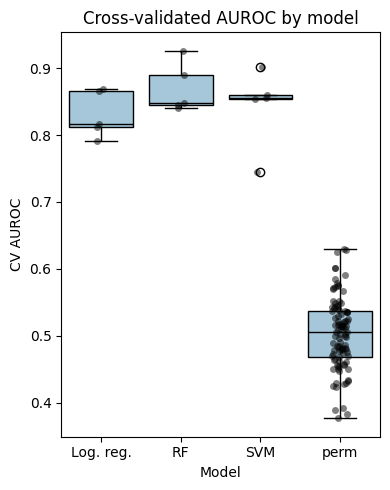

,model,fold,auroc
0,logreg,0,0.866279
1,logreg,1,0.790698
2,logreg,2,0.868386
3,logreg,3,0.812625
4,logreg,4,0.817276


In [2]:
# Combine CV AUROC results from all models and visualize as boxplot

cv_logreg = pd.read_csv("output/logreg/cv_auroc_logreg.csv")
cv_rf = pd.read_csv("output/random_forest/cv_auroc_rf.csv")
cv_svm = pd.read_csv("output/svm/cv_auroc_svm.csv")
cv_negative = pd.read_csv("output/random_forest/cv_auroc_rf_perm.csv")

cv_all = pd.concat([cv_logreg, cv_rf, cv_svm, cv_negative], ignore_index=True)

plt.figure(figsize=(4, 5))
ax = sns.boxplot(
    data=cv_all,
    x="model",
    y="auroc",
    color="#9ecae1",
    linecolor="black",
    linewidth=1.0
)

sns.stripplot(data=cv_all, x="model", y="auroc", color="black", alpha=0.5)
plt.ylabel("CV AUROC")
plt.xlabel("Model")
plt.title("Cross-validated AUROC by model")

# Rename x-axis labels in the order of the categorical 'model' values
ax.set_xticklabels(["Log. reg.", "RF", "SVM", "perm"])

plt.tight_layout()
plt.savefig("output/cv_auroc_boxplot_all_models.pdf", dpi=300, bbox_inches="tight")
plt.savefig("output/cv_auroc_boxplot_all_models.png", dpi=300, bbox_inches="tight")
plt.show()

cv_all.head()